# 05 – Adverse Event Signal Detection

Compute drug–AE disproportionality metrics from FAERS: PRR, ROR, chi-squared, and an Evans-style screening criterion (count ≥ 3, PRR ≥ 2, chi-squared ≥ 4). Focused outputs can prioritize serious and immune-related reports.

These are pharmacovigilance **signals**, not causal conclusions.

In [10]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parent
if not (ROOT/"data").exists(): ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

from src.preprocessing import serious_report_flag, flag_immune_reactions
from src.faers_signals import compute_signals, rank_signals
from src.visualization import plot_signal_volcano

path = ROOT/"data/raw/faers/fda_adverse_events_2015_2026_CLEAN.csv"
if not path.exists(): path = ROOT/"fda_adverse_events_2015_2026_CLEAN.csv"
df = pd.read_csv(path)

df["is_serious_report"] = serious_report_flag(df)
df["is_immune_related"] = flag_immune_reactions(
    df["reactions"].fillna("").astype(str) + " " + df["primary_reaction"].fillna("").astype(str)
)

signals = compute_signals(df, min_count=3)
signals = rank_signals(signals)
display(signals.head(30))

,suspect_drug,ae,a,b,c,d,PRR,ROR,chi2,p_value,evans_signal,signal_strength
93913,CLARITHROMYCIN ACTAVIS,hearing aid therapy,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
180948,FOLIC ACID (UNKNOWN),haemoglobin s,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
224813,IRON (SALT NOT SPECIFIED),pica,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
132611,DOXORUBICINHYDROCHLORID TEVA 2 MG/ML KONZENTRA...,application site necrosis,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
50425,AZEDRA,sarcomatoid carcinoma,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
261747,MESACOL,burglary victim,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
295105,OBDS DEVICE (MEDICAL DEVICE),application site induration,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
354809,RID 1-2-3 SYSTEM,septic arthritis streptococcal,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
439897,VITAMIN B12 [VITAMIN B12 NOS],hypervitaminosis b12,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778
118710,DEXALTIN,oral papilloma,1,0,1,527998,527999.0,inf,263999.499999,0.0,False,16.297778


In [11]:
focused = signals[
    (signals["a"] >= 3) &
    signals["evans_signal"]
].copy()

display(focused.head(50))
print("Evans-style signals:", len(focused))

,suspect_drug,ae,a,b,c,d,PRR,ROR,chi2,p_value,evans_signal,signal_strength
14640,ADUHELM,amyloid related imaging abnormality-microhaemo...,3,2,1,527994,316797.000000,7.919910e+05,237598.049988,0.0,True,15.760605
14641,ADUHELM,amyloid related imaging abnormality-oedema/eff...,4,1,2,527993,211198.000000,1.055986e+06,281597.866649,0.0,True,15.397616
222436,IOFLUPANE I-123,radioisotope scan abnormal,3,1,2,527994,197998.500000,7.919910e+05,237598.049988,0.0,True,15.290605
126938,DINUTUXIMAB,neuroblastoma recurrent,25,23,3,527949,91658.333333,1.912859e+05,245521.055799,0.0,True,14.528620
250575,LITHIOFOR,morose,3,0,6,527991,87999.500000,inf,175997.999989,0.0,True,14.404656
309234,OSPOLOT,congenital cyst,3,1,5,527991,79199.400000,3.167946e+05,148497.374984,0.0,True,14.256819
319523,PARATHYROID HORMONE,recalled product,176,348,3,527473,59055.837150,8.892265e+04,174251.398022,0.0,True,14.003321
59558,BIOTIN,laboratory test interference,5,1,8,527986,54999.375000,3.299912e+05,169226.858934,0.0,True,13.924846
290820,NITISINONE,lenticular opacities,34,28,6,527932,48252.397849,1.068434e+05,246095.672750,0.0,True,13.887591
34567,ANTI-INHIBITOR COAGULANT COMPLEX,anti factor viii antibody increased,6,20,2,527972,60920.076923,7.919580e+04,91378.499932,0.0,True,13.873029


Evans-style signals: 53431


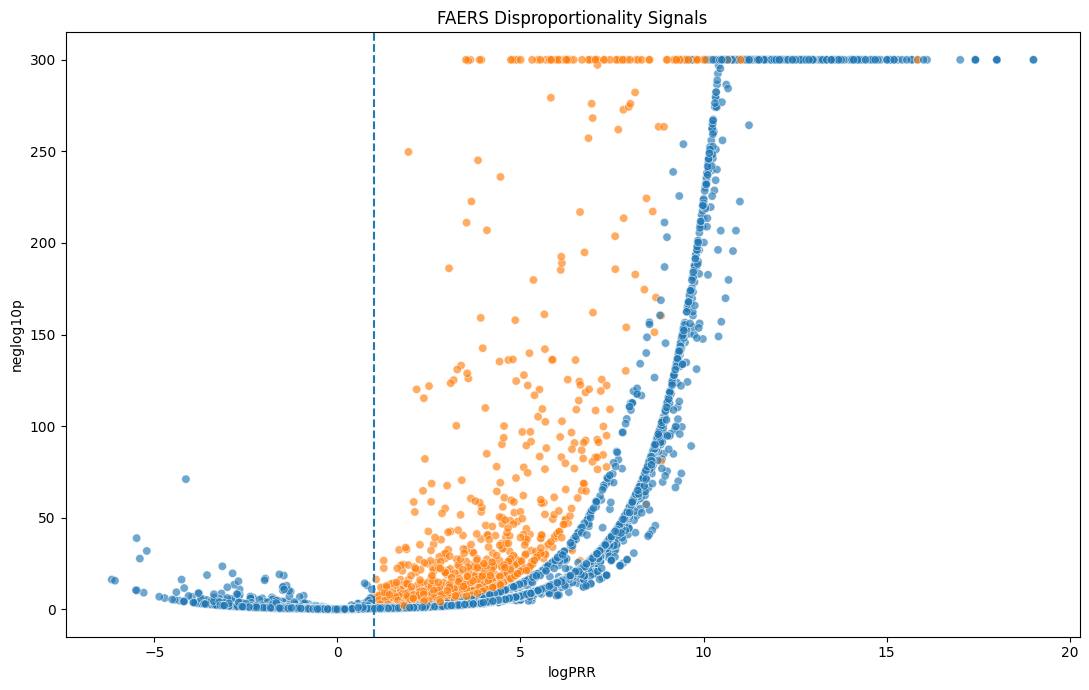

In [12]:
FIG = ROOT/"reports/figures"
plot_signal_volcano(signals, FIG/"faers_signal_volcano.png")
plt.show()

In [13]:
OUT = ROOT/"data/processed/faers"
OUT.mkdir(parents=True, exist_ok=True)
signals.to_parquet(OUT/"faers_drug_ae_signals.parquet")
focused.to_csv(OUT/"faers_focused_signals.csv", index=False)
print("Signal outputs saved.")

Signal outputs saved.


### Interpretation

A large PRR can reflect a true safety concern, but also reporting stimulation, confounding by indication, co-medications, differential utilization, missing exposure denominators, or terminology artifacts.

**TODO:** implement validated MedDRA grouping, duplicate/case-level processing, confidence intervals, multiple-testing controls, and stratified analyses.